In [1]:
#Train LSTM and GRU networks for the time series prediction problem from step 1

from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
import matplotlib as mpl

def plot_learning_curves(loss, val_loss, title=None):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    if title:
        plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)


def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0454 - val_loss: 0.0221
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0148 - val_loss: 0.0113
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0076 - val_loss: 0.0050
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0047 - val_loss: 0.0039
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0040 - val_loss: 0.0035
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0037 - val_loss: 0.0033
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0030 - val_loss: 0.0028
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/st

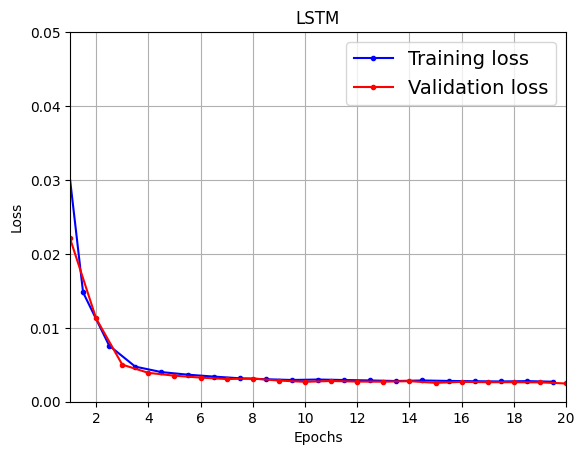

In [2]:
#LSTM

lstm_model = keras.Sequential([
    keras.Input(shape=(50, 1)),
    keras.layers.LSTM(20),
    keras.layers.Dense(1)
])

lstm_model.compile(loss="mse", optimizer="adam")
lstm_model.fit(X_train, y_train, epochs=20,
               validation_data=(X_test, y_test))

lstm_mse = lstm_model.evaluate(X_valid, y_valid)
print(f"LSTM MSE: {lstm_mse}")

plot_learning_curves(lstm_model.history.history["loss"], lstm_model.history.history["val_loss"], title="LSTM")
plt.show()

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0471 - val_loss: 0.0172
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0120 - val_loss: 0.0072
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0059 - val_loss: 0.0050
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0049 - val_loss: 0.0043
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0045 - val_loss: 0.0041
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0040 - val_loss: 0.0038
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10

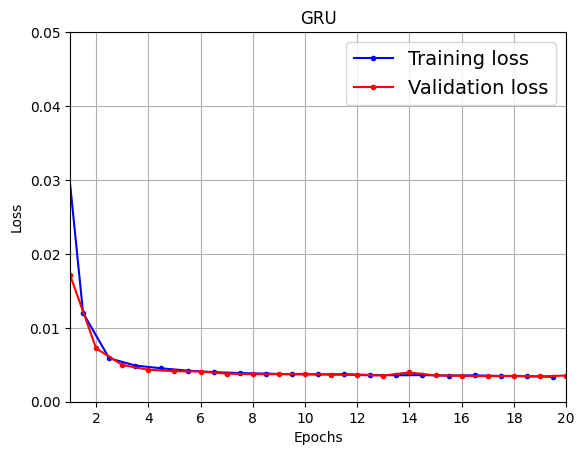

In [3]:
#GRU

lstm_model = keras.Sequential([
    keras.Input(shape=(50, 1)),
    keras.layers.GRU(20),
    keras.layers.Dense(1)
])

lstm_model.compile(loss="mse", optimizer="adam")
lstm_model.fit(X_train, y_train, epochs=20,
               validation_data=(X_test, y_test))

gru_mse = lstm_model.evaluate(X_valid, y_valid)
print(f"GRU MSE: {gru_mse}")

plot_learning_curves(lstm_model.history.history["loss"], lstm_model.history.history["val_loss"], title="GRU")
plt.show()